### Código para graficar métricas de entrenamiento usando TRIAL 12

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [17]:
data_dir = os.path.join("..", "output")
df = pd.read_csv(os.path.join(data_dir, "Trial_2", "resultados_metricas_entrenamiento.csv"))
display(df.head())



,epoch,train_loss,val_loss,test_loss,train_auc,val_auc,test_auc,train_acc,val_acc,test_acc,train_precision,val_precision,test_precision,train_recall,val_recall,test_recall,train_f1,val_f1,test_f1
0,1,0.693235,0.686916,0.686849,0.468729,0.694015,0.695645,0.500000,0.500000,0.50000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,0.686490,0.687605,0.686422,0.690295,0.758504,0.763161,0.500000,0.640795,0.64527,0.000000,0.602325,0.605504,0.000000,0.828777,0.833728,0.000000,0.697634,0.701521
2,3,0.691974,0.882738,0.881855,0.756505,0.462208,0.467027,0.636048,0.500000,0.50000,0.596142,0.000000,0.000000,0.843581,0.000000,0.000000,0.698599,0.000000,0.000000
3,4,0.898730,0.687558,0.687115,0.460534,0.682180,0.688799,0.500000,0.500000,0.50000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,0.687040,0.674814,0.674473,0.680374,0.770384,0.774231,0.500000,0.500000,0.50000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


configuración general de estilo

In [8]:
sns.set(style='whitegrid', context='notebook', font_scale=1.2)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['lines.linewidth'] = 2

##### Gráfico 1: Pérdida (Loss)

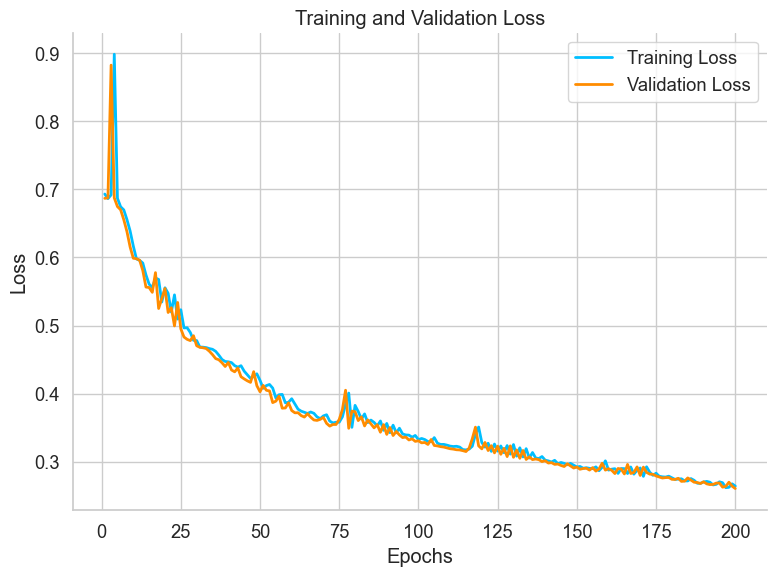

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(df['epoch'], df['train_loss'], label='Training Loss', color='deepskyblue')
plt.plot(df['epoch'], df['val_loss'], label='Validation Loss', color='darkorange')
#plt.plot(df['epoch'], df['test_loss'], label='Test Loss', linestyle='--', color='forestgreen')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Ambas curvas (train/val) descienden suavemente y permanecen cercanas entre sí → no hay overfitting evidente.

##### Gráfico 2: AUC (Area Under Curve)

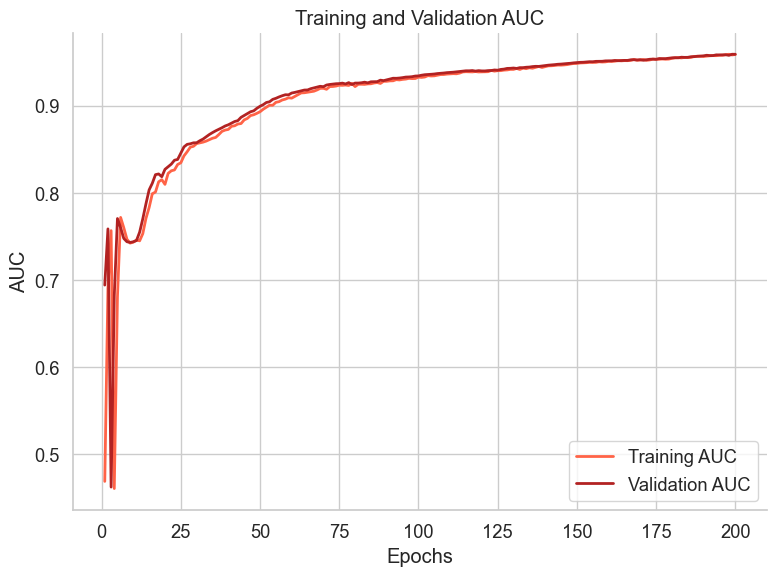

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(df['epoch'], df['train_auc'], label='Training AUC', color='tomato')
plt.plot(df['epoch'], df['val_auc'], label='Validation AUC', color='firebrick')
#plt.plot(df['epoch'], df['test_auc'], label='Test AUC', linestyle='--', color='forestgreen')
plt.title('Training and Validation AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Mejora constante en ambas curvas y se estabiliza arriba de 0.95 → excelente capacidad de discriminación.

##### Gráfico 3: Accuracy (Acc)

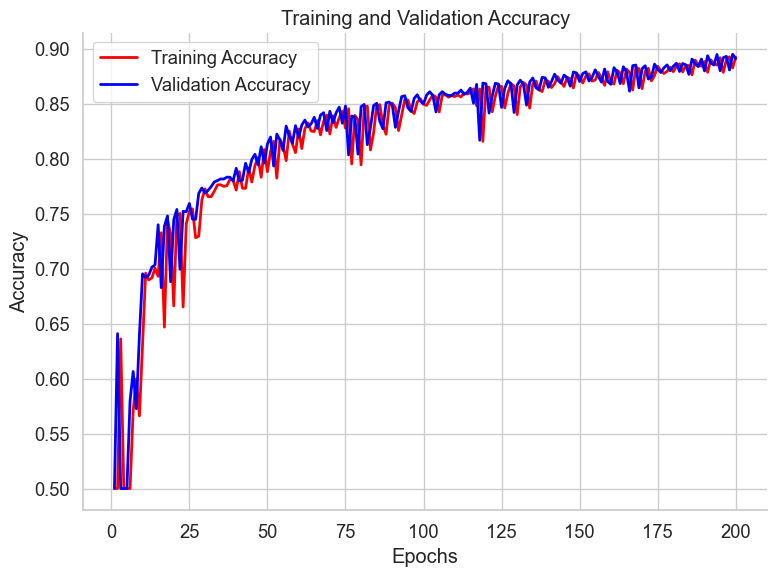

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(df['epoch'], df['train_acc'], label='Training Accuracy', color='red')
plt.plot(df['epoch'], df['val_acc'], label='Validation Accuracy', color='blue')
#plt.plot(df['epoch'], df['test_acc'], label='Test Accuracy', linestyle='--', color='green')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Aumenta con el tiempo y valida bien el aprendizaje general.

##### Gráfico 4: F1-Score

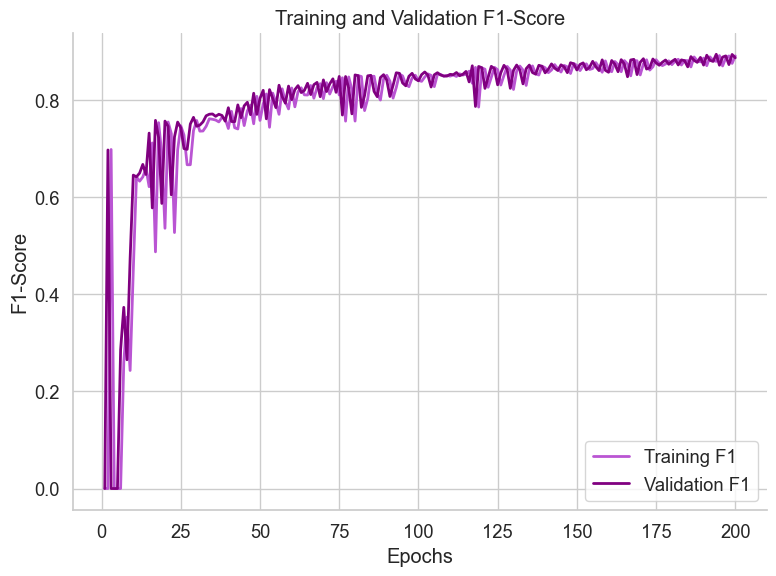

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(df['epoch'], df['train_f1'], label='Training F1', color='mediumorchid')
plt.plot(df['epoch'], df['val_f1'], label='Validation F1', color='purple')
#plt.plot(df['epoch'], df['test_f1'], label='Test F1', linestyle='--', color='indigo')
plt.title('Training and Validation F1-Score')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Gráfico 5: Precision

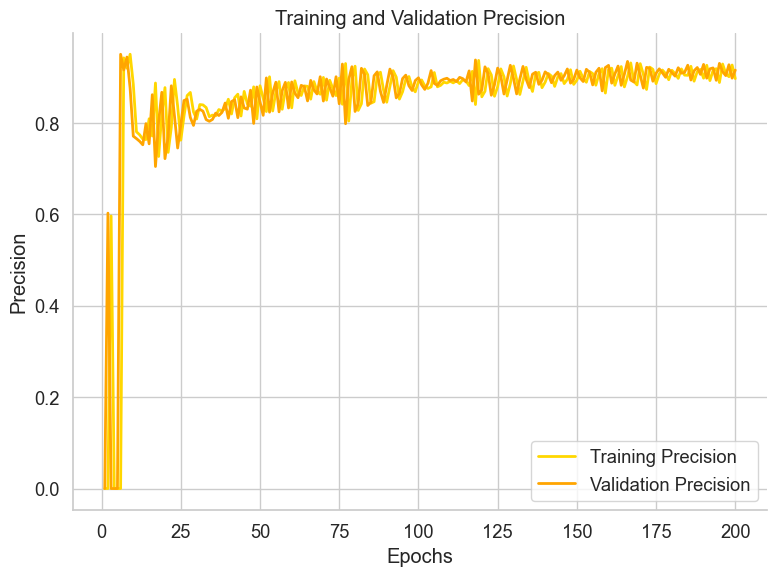

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(df['epoch'], df['train_precision'], label='Training Precision', color='gold')
plt.plot(df['epoch'], df['val_precision'], label='Validation Precision', color='orange')
#plt.plot(df['epoch'], df['test_precision'], label='Test Precision', linestyle='--', color='darkgoldenrod')
plt.title('Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Gráfico 6: Recall

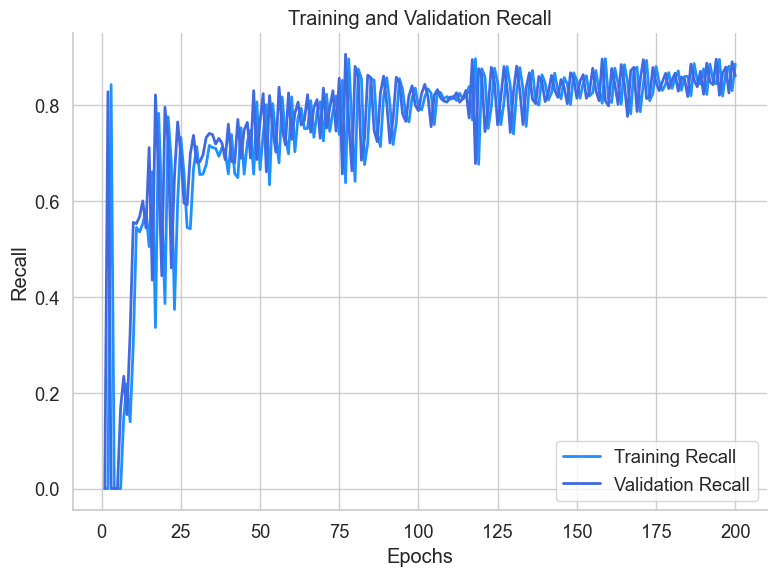

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(df['epoch'], df['train_recall'], label='Training Recall', color='dodgerblue')
plt.plot(df['epoch'], df['val_recall'], label='Validation Recall', color='royalblue')
#plt.plot(df['epoch'], df['test_recall'], label='Test Recall', linestyle='--', color='navy')
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


F1-Score, Precision y Recall: Siguen un patrón muy similar, alto rendimiento en todas estas métricas, lo cual indica:
- Buen balance entre falsos positivos y falsos negativos.
- El modelo no está sesgado hacia una clase.

In [18]:
# Mejor epoch
best_epoch = df['val_auc'].idxmax()

# extraer fila del mejor epoch
best_metrics = df.iloc[best_epoch]

# Crear tabla resumen
summary = {
    'Best Epoch': best_epoch + 1,  # +1 porque idxmax() es 0-based
    'Train Loss': best_metrics['train_loss'],
    'Val Loss': best_metrics['val_loss'],
    'Test Loss': best_metrics['test_loss'],
    'Train AUC': best_metrics['train_auc'],
    'Val AUC': best_metrics['val_auc'],
    'Test AUC': best_metrics['test_auc'],
    'Train Accuracy': best_metrics['train_acc'],
    'Val Accuracy': best_metrics['val_acc'],
    'Test Accuracy': best_metrics['test_acc'],
    'Train F1': best_metrics['train_f1'],
    'Val F1': best_metrics['val_f1'],
    'Test F1': best_metrics['test_f1'],
    'Train Precision': best_metrics['train_precision'],
    'Val Precision': best_metrics['val_precision'],
    'Test Precision': best_metrics['test_precision'],
    'Train Recall': best_metrics['train_recall'],
    'Val Recall': best_metrics['val_recall'],
    'Test Recall': best_metrics['test_recall'],
}

# Convertir a DataFrame para guardar o mostrar
summary_df = pd.DataFrame([summary])

# Guardar a Excel
summary_df.to_excel("tabla_resumen_mejor_epoch.xlsx", index=False)

print(summary_df)

   Best Epoch  Train Loss  Val Loss  Test Loss  Train AUC   Val AUC  Test AUC  \
0         199    0.267288  0.263851    0.26205   0.958134  0.958931  0.959642   

   Train Accuracy  Val Accuracy  Test Accuracy  Train F1    Val F1   Test F1  \
0        0.882378      0.894805       0.894491  0.875996  0.894431  0.894137   

   Train Precision  Val Precision  Test Precision  Train Recall  Val Recall  \
0         0.926252       0.897624         0.89715      0.830913     0.89126   

   Test Recall  
0     0.891144  
